#A. Simulate a stationary MA(3) process yt = 0.9θ(t−1) + 0.3θ(t−2) + 0.2θ(t−3). To do so, use the ArmaProcess function from the statsmodels library

In [ ]:
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
import random

#B. Generate 10,000 samples.


In [ ]:
ma3 = np.array([1, 0.9, 0.3,0.2])
ar3 = np.array([1, 0, 0,0])
MA3_process = ArmaProcess(ar3, ma3).generate_sample(nsample=10000)


#C. Plot your simulated moving average

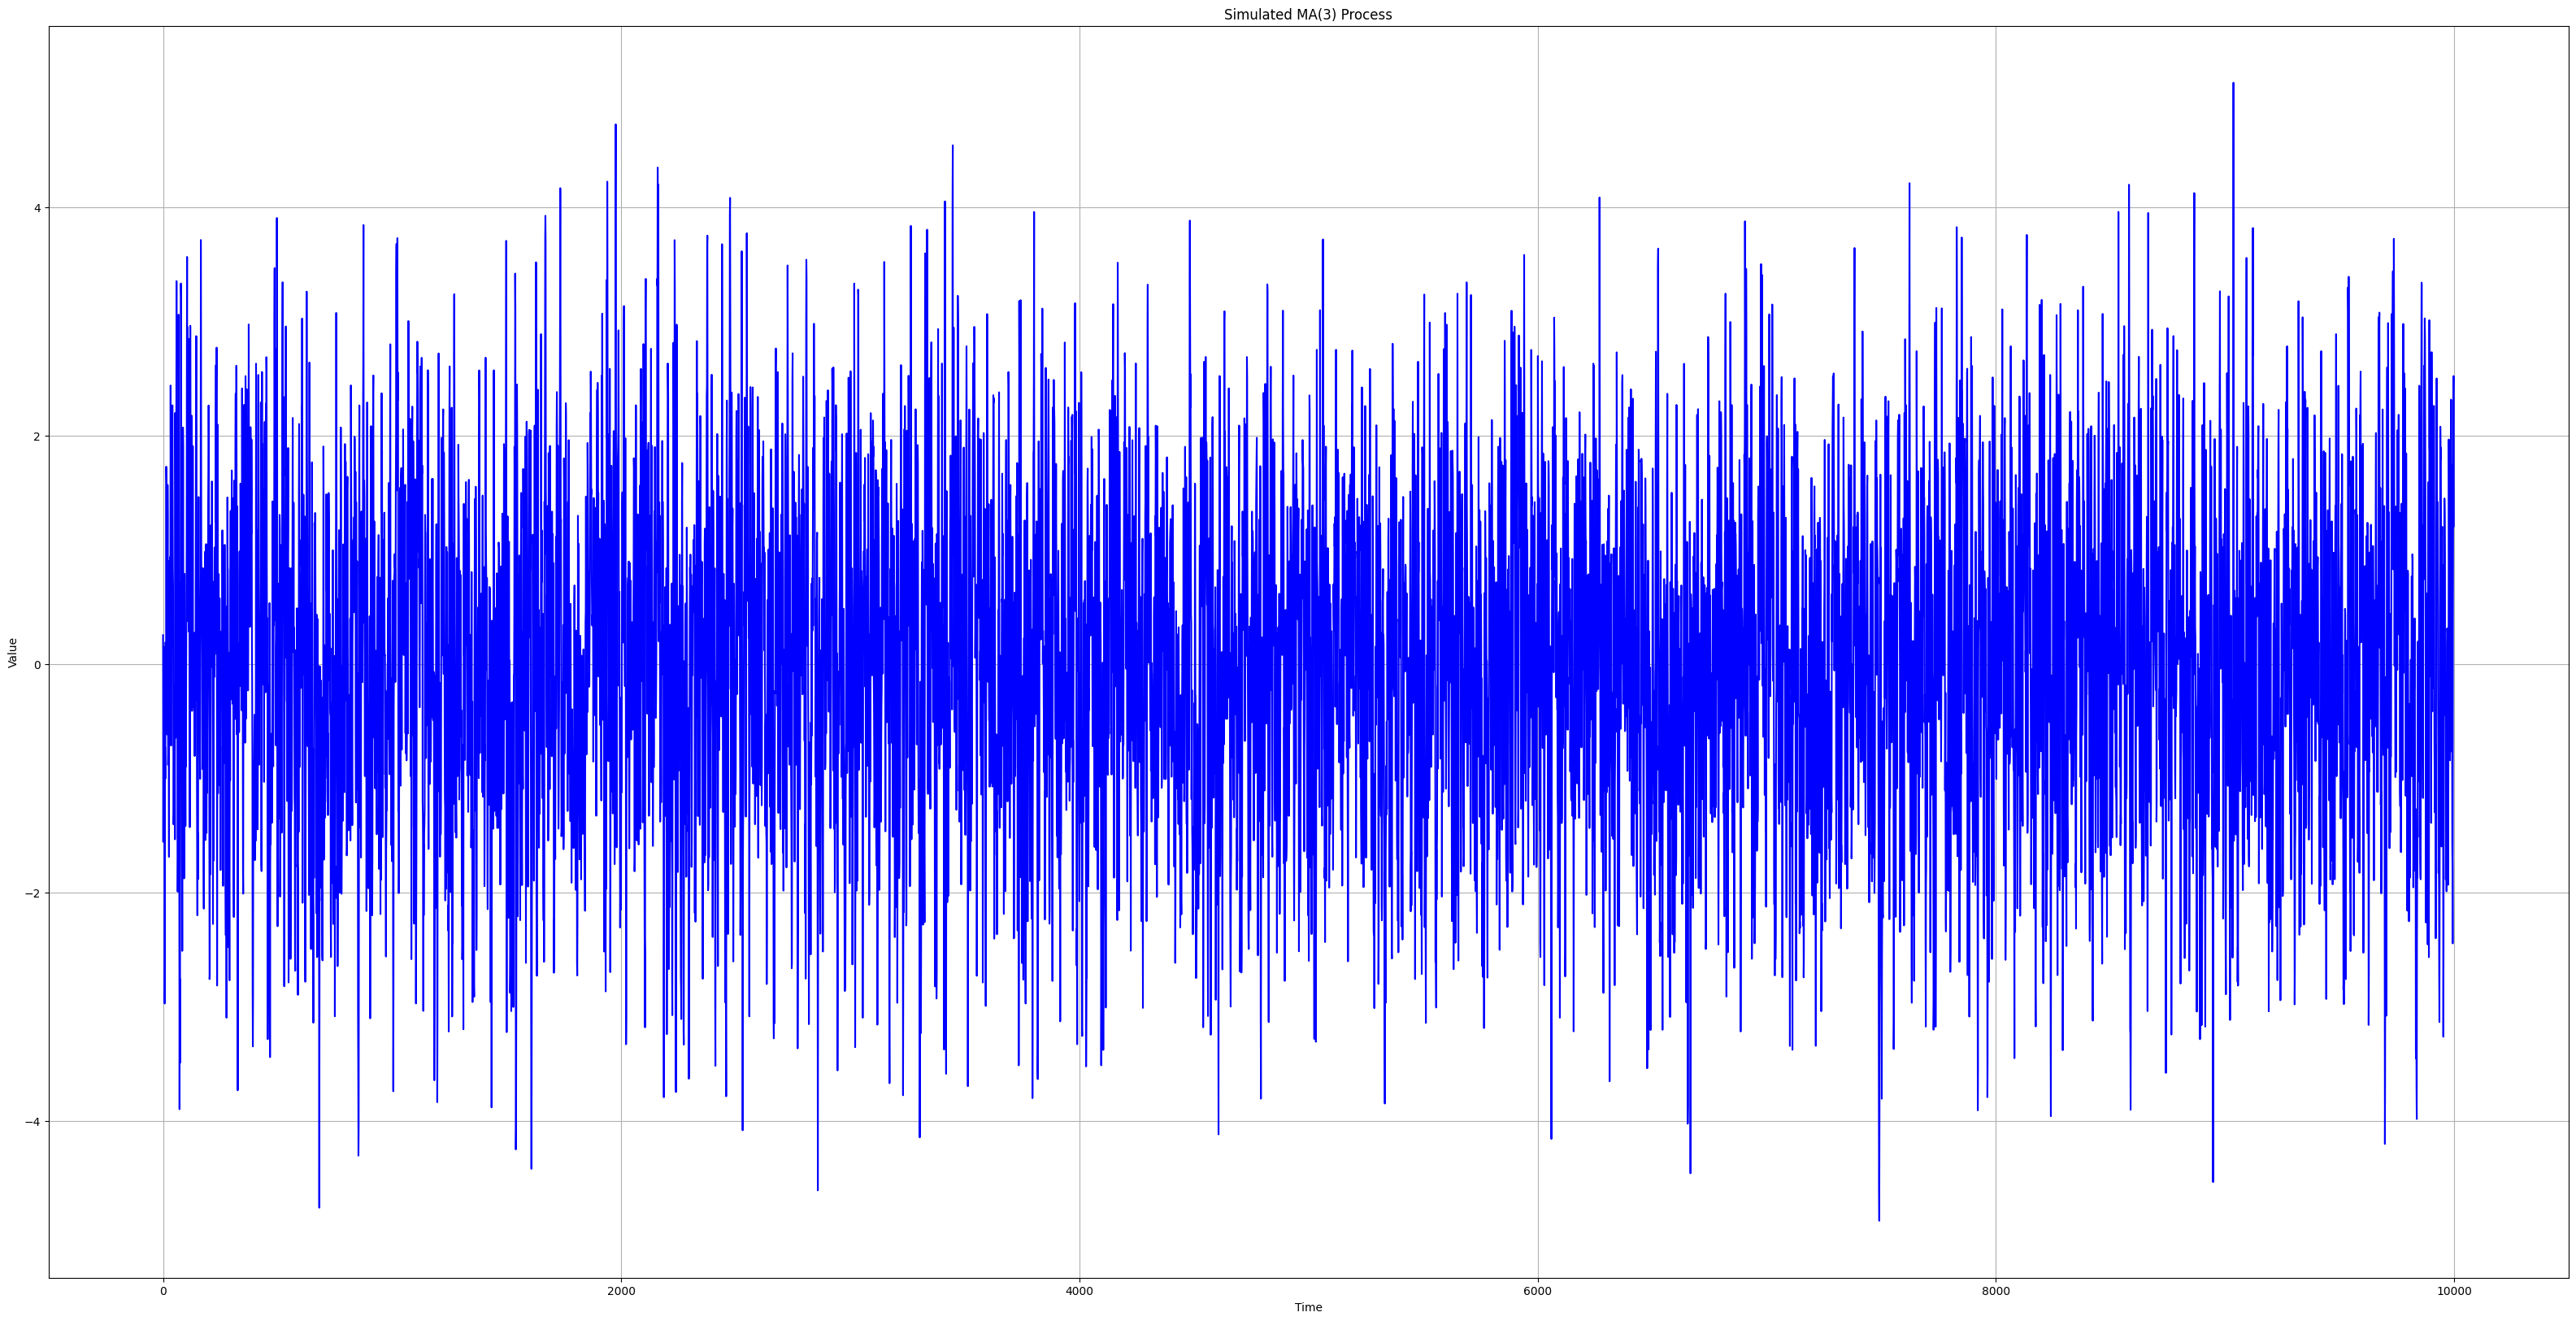

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(40, 20))
plt.plot(MA3_process, color='blue')
plt.title('Simulated MA(3) Process')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True)
plt.show()


#D. Run the ADF test, and check if the process is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller


ADF_result = adfuller(MA3_process)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')


ADF Statistic: -21.925266080439062
p-value: 0.0


#The process is stationary(small p(less then 0.05) and large negative ADF Statistic)

#E. Plot the ACF, and see if there are significant coefficients after lag 3

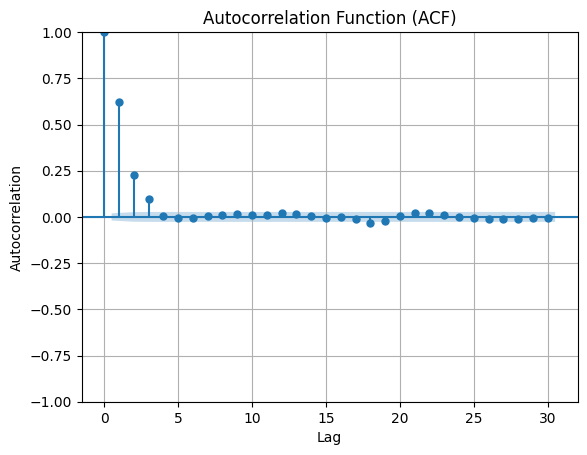

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(MA3_process, lags=30)


plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.grid(True)

plt.show()


There are significant coefficients up until lag 3. Then
they abruptly become non-significant, as they remain
in the shaded area of the plot.

However, in several places after 3, you can notice a slight deviation from the confidence interval

#Separate your simulated series into train and test sets. Take the first 9,800 timesteps for the train set, and assign the rest to the test set.

In [ ]:
# Разделение на train и test
train_set = MA3_process[:9800]
test_set = MA3_process[9800:]


#G. Make forecasts over the test set. Use two baseline models of your choice, and an MA(3) model. Make sure you repeatedly forecast 3 timesteps at a time.

In [ ]:

from sklearn.metrics import mean_squared_error



# 1 способ: заполнить всё средним значением
train_mean=np.mean(train_set)
train_mean_pred = np.full(len(test_set), train_mean)
print(mean_squared_error(test_set,train_mean_pred))

# 2 способ: взять и заполнить predict последним элементом test
train_last = train_set[-1]
train_last_pred = np.full(len(test_set), train_last)
print(mean_squared_error(test_set,train_last_pred))

2.388432929282643
3.1076000646300743


In [ ]:


# Define baseline models
# Baseline 1: Use the last observed value as the forecast
def baseline_last_observed(train_set, test_set):
    forecasts = [train_set[-1]] * len(test_set)
    return forecasts

# Baseline 2: Use the average of the last few observed values as the forecast
def baseline_average(train_set, test_set, window_size=3):
    forecasts = [np.mean(train_set[-window_size:])]*len(test_set)
    return forecasts

# MA(3) model forecast function
def ma3_forecast(train_set, test_set):
    forecasts = []
    for i in range(len(test_set)):
        if i < 3:
            forecasts.append(train_set[-1])
        else:
            forecast = ma3[0] * test_set[i-1] + ma3[1] * test_set[i-2] + ma3[2] * test_set[i-3]
            forecasts.append(forecast)
    return forecasts

# Function to recursively forecast 3 timesteps at a time
def recursive_forecast(model_forecast, test_set):
    forecasts = []
    for i in range(0, len(test_set), 3):
        if i + 3 <= len(test_set):
            forecasts.extend(model_forecast(test_set[:i+3], test_set[i+3:i+6]))
    return forecasts


baseline1_forecasts = recursive_forecast(baseline_last_observed, test_set)
baseline2_forecasts = recursive_forecast(baseline_average, test_set)
ma3_forecasts = recursive_forecast(ma3_forecast, test_set)

# Print forecasts
print("Baseline 1 forecasts:", len(baseline1_forecasts))
print("Baseline 2 forecasts:", len(baseline2_forecasts))
print("MA(3) forecasts:", ma3_forecasts)


Baseline 1 forecasts: 197
Baseline 2 forecasts: 197
MA(3) forecasts: [-1.8461648002347315, -1.8461648002347315, -1.8461648002347315, 1.1522512138690635, 1.1522512138690635, 1.1522512138690635, -2.420981523278957, -2.420981523278957, -2.420981523278957, 0.5751511557141666, 0.5751511557141666, 0.5751511557141666, 0.36275611786126427, 0.36275611786126427, 0.36275611786126427, -1.6600880419344635, -1.6600880419344635, -1.6600880419344635, -1.1900714480391215, -1.1900714480391215, -1.1900714480391215, -0.2058137037975103, -0.2058137037975103, -0.2058137037975103, 0.6780977407413441, 0.6780977407413441, 0.6780977407413441, 2.376593894161517, 2.376593894161517, 2.376593894161517, 0.4381482908483955, 0.4381482908483955, 0.4381482908483955, 1.3753474100638887, 1.3753474100638887, 1.3753474100638887, 2.148255854594848, 2.148255854594848, 2.148255854594848, -0.730778719045798, -0.730778719045798, -0.730778719045798, 1.3053124484326488, 1.3053124484326488, 1.3053124484326488, 1.2503923204437644, 1

#H. Plot your forecasts on the same graph.

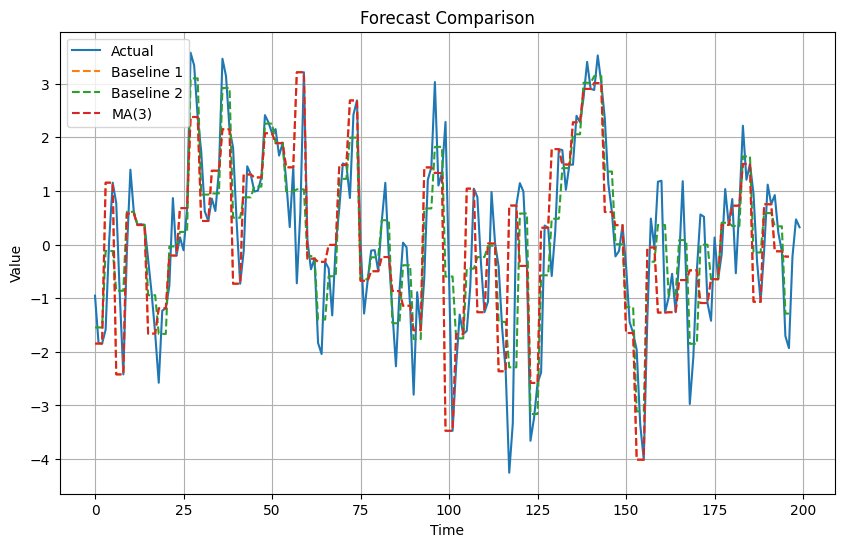

In [ ]:


# Plot the forecasts
plt.figure(figsize=(10, 6))
plt.plot(test_set, label='Actual')

# Plot Baseline 1 forecasts
plt.plot(baseline1_forecasts, label='Baseline 1', linestyle='--')

# Plot Baseline 2 forecasts
plt.plot(baseline2_forecasts, label='Baseline 2', linestyle='--')

# Plot MA(3) forecasts
plt.plot(ma3_forecasts, label='MA(3)', linestyle='--')

plt.title('Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


#I. Measure the MSE, identify your champion model and draw the MSEs in a bar plot

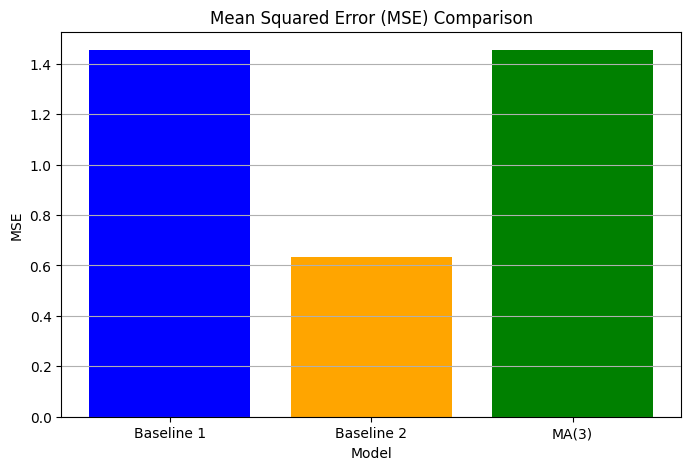

MSEs:
Baseline 1: 1.454809590585107
Baseline 2: 0.632355437233981
MA(3): 1.454809590585107

Champion Model:
The champion model is Baseline 2 with MSE: 0.632355437233981


In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate MSE for each model
mse_baseline1 = mean_squared_error(test_set[:-3], baseline1_forecasts)
mse_baseline2 = mean_squared_error(test_set[:-3], baseline2_forecasts)
mse_ma3 = mean_squared_error(test_set[:-3], ma3_forecasts)

# Identify the champion model
champion_model = min([(mse_baseline1, 'Baseline 1'), (mse_baseline2, 'Baseline 2'), (mse_ma3, 'MA(3)')], key=lambda x: x[0])

# Plot the MSEs
models = ['Baseline 1', 'Baseline 2', 'MA(3)']
mses = [mse_baseline1, mse_baseline2, mse_ma3]

plt.figure(figsize=(8, 5))
plt.bar(models, mses, color=['blue', 'orange', 'green'])
plt.title('Mean Squared Error (MSE) Comparison')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.grid(axis='y')
plt.show()

print("MSEs:")
for model, mse in zip(models, mses):
    print(f"{model}: {mse}")

print("\nChampion Model:")
print(f"The champion model is {champion_model[1]} with MSE: {champion_model[0]}")


The best model:Baseline 2-Using the average of the last few observed values as the forecast.




